In [62]:
import pandas as pd
from analysis_utils import parse_salary

df = pd.read_csv("../data/jobs.csv")

df = df.dropna(subset=["salary"])
df["job_title"] = df["positionName"].str.lower()
df = df.drop_duplicates()

# Convert salary to numeric
df["salary_numeric"] = df["salary"].apply(parse_salary)
df = df.dropna(subset=["salary_numeric"])

df["salary_numeric"].mean()
df["job_title"].value_counts().head(25)


job_title
software developer - ai trainer (contract)                                 2
manager, enterprise generative artificial intelligence                     2
senior data scientist                                                      2
senior specialist, cloud data engineer                                     2
data analyst                                                               2
principal data engineer                                                    2
sr. data scientist                                                         2
ai applications sales engineer                                             1
sr. ai strategist                                                          1
marketing data scientist                                                   1
vp, digital product strategy                                               1
rating analyst, review & validation                                        1
analytics director, customer experience                           

In [63]:
# Skills Analysis: Extract in-demand technical skills from job descriptions
import numpy as np
from collections import Counter

from analysis_utils import extract_skills, TECH_SKILLS

tech_skills = TECH_SKILLS

# Extract skills from job descriptions
print("Extracting skills from job descriptions...")
df['skills'] = df['description'].apply(extract_skills)
df['skill_count'] = df['skills'].apply(len)

# Count skill frequency across all jobs
all_skills = []
for skills_list in df['skills']:
    all_skills.extend(skills_list)

skill_counts = Counter(all_skills)
top_skills = skill_counts.most_common(30)

print(f"\nTotal jobs analyzed: {len(df)}")
print(f"Jobs with skills identified: {len(df[df['skill_count'] > 0])}")
print(f"\nTop 30 In-Demand Skills:")
for skill, count in top_skills:
    print(f"  {skill}: {count} jobs ({count/len(df)*100:.1f}%)")


Extracting skills from job descriptions...

Total jobs analyzed: 85
Jobs with skills identified: 72

Top 30 In-Demand Skills:
  machine learning: 39 jobs (45.9%)
  python: 37 jobs (43.5%)
  sql: 37 jobs (43.5%)
  r: 26 jobs (30.6%)
  spark: 18 jobs (21.2%)
  aws: 18 jobs (21.2%)
  azure: 18 jobs (21.2%)
  tableau: 16 jobs (18.8%)
  power bi: 10 jobs (11.8%)
  data modeling: 10 jobs (11.8%)
  gcp: 10 jobs (11.8%)
  snowflake: 8 jobs (9.4%)
  data governance: 8 jobs (9.4%)
  go: 8 jobs (9.4%)
  java: 8 jobs (9.4%)
  deep learning: 7 jobs (8.2%)
  pytorch: 7 jobs (8.2%)
  nlp: 7 jobs (8.2%)
  javascript: 7 jobs (8.2%)
  ci/cd: 7 jobs (8.2%)
  microservices: 7 jobs (8.2%)
  kafka: 6 jobs (7.1%)
  tensorflow: 6 jobs (7.1%)
  hadoop: 5 jobs (5.9%)
  data quality: 5 jobs (5.9%)
  etl: 5 jobs (5.9%)
  natural language processing: 5 jobs (5.9%)
  kubernetes: 5 jobs (5.9%)
  apache spark: 4 jobs (4.7%)
  llm: 4 jobs (4.7%)


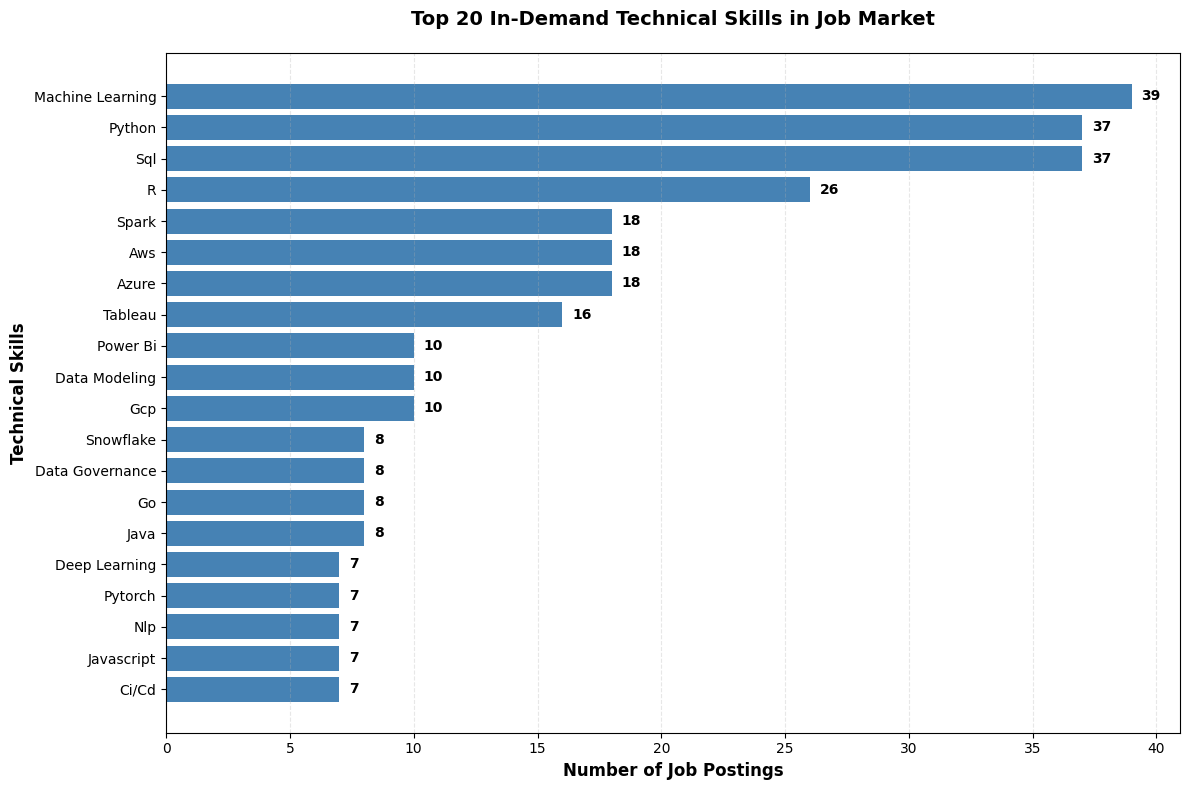


Insight: Machine Learning appears in 39 job postings (45.9% of all jobs)


In [64]:
# Visualization 1: Top In-Demand Skills Bar Chart
import matplotlib.pyplot as plt

# Prepare data for visualization
top_20_skills = skill_counts.most_common(20)
skills_names = [skill[0].title() for skill in top_20_skills]
skills_counts = [skill[1] for skill in top_20_skills]

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(skills_names, skills_counts, color='steelblue')
plt.xlabel('Number of Job Postings', fontsize=12, fontweight='bold')
plt.ylabel('Technical Skills', fontsize=12, fontweight='bold')
plt.title('Top 20 In-Demand Technical Skills in Job Market', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()  # Show highest at top
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, v in enumerate(skills_counts):
    plt.text(v + max(skills_counts)*0.01, i, f'{v}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nInsight: {skills_names[0]} appears in {skills_counts[0]} job postings ({skills_counts[0]/len(df)*100:.1f}% of all jobs)")

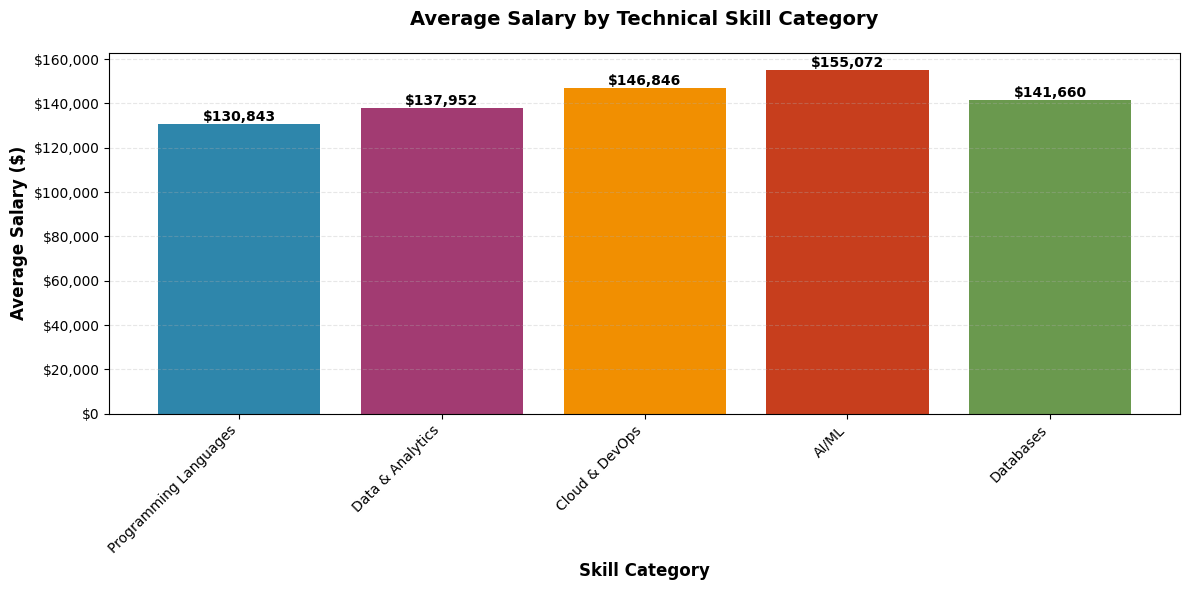


Career Insight: AI/ML roles have the highest average salary at $155,072
Career Insight: Programming Languages roles average $130,843


In [65]:
# Visualization 2: Salary Distribution by Skill Category
# Categorize skills and analyze salary trends
skill_categories = {
    'Programming Languages': ['python', 'java', 'javascript', 'typescript', 'sql', 'r', 'scala', 'go', 'c++', 'c#'],
    'Data & Analytics': ['pandas', 'numpy', 'scikit-learn', 'tableau', 'power bi', 'looker', 'spark'],
    'Cloud & DevOps': ['aws', 'azure', 'gcp', 'docker', 'kubernetes', 'terraform', 'jenkins'],
    'AI/ML': ['machine learning', 'deep learning', 'nlp', 'tensorflow', 'pytorch', 'keras', 'llm'],
    'Databases': ['postgresql', 'mysql', 'mongodb', 'redis', 'snowflake', 'redshift', 'bigquery']
}

# Calculate average salary for each category
category_salaries = {}
for category, skills in skill_categories.items():
    # Find jobs that mention any skill in this category
    mask = df['skills'].apply(lambda x: any(skill in x for skill in skills))
    category_jobs = df[mask]
    if len(category_jobs) > 0:
        avg_salary = category_jobs['salary_numeric'].mean()
        category_salaries[category] = avg_salary

# Create bar chart
if category_salaries:
    categories = list(category_salaries.keys())
    salaries = list(category_salaries.values())
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(categories, salaries, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'])
    plt.xlabel('Skill Category', fontsize=12, fontweight='bold')
    plt.ylabel('Average Salary ($)', fontsize=12, fontweight='bold')
    plt.title('Average Salary by Technical Skill Category', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Format y-axis as currency
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # Add value labels on bars
    for bar, salary in zip(bars, salaries):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'${salary:,.0f}',
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    max_category = max(category_salaries, key=category_salaries.get)
    min_category = min(category_salaries, key=category_salaries.get)
    print(f"\nCareer Insight: {max_category} roles have the highest average salary at ${category_salaries[max_category]:,.0f}")
    print(f"Career Insight: {min_category} roles average ${category_salaries[min_category]:,.0f}")

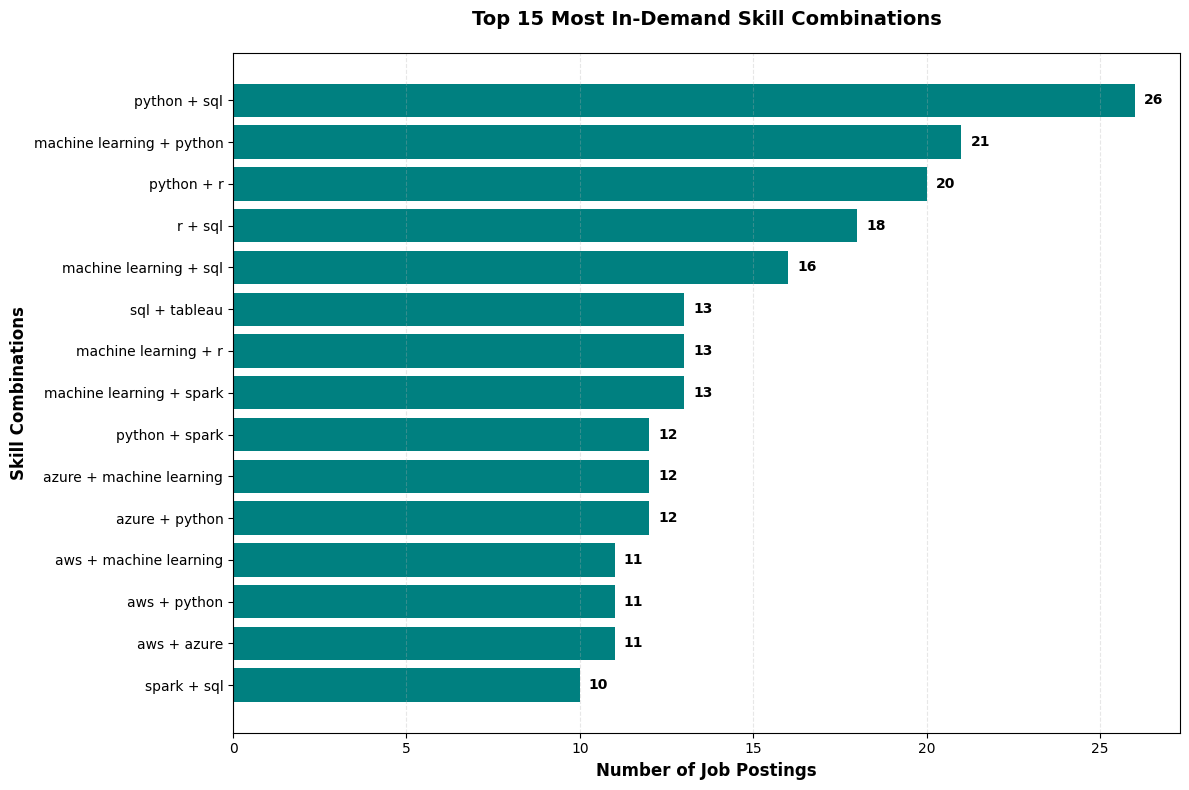


Insight: The combination 'python + sql' appears in 26 job postings
Career Insight: Developing complementary skills increases job market opportunities


In [66]:
# Visualization 3: Skills Combination Analysis - Most Valuable Skill Pairs
from itertools import combinations

# Find most common skill pairs
skill_pairs = []
for skills_list in df['skills']:
    if len(skills_list) >= 2:
        # Get all pairs of skills in this job
        pairs = list(combinations(sorted(skills_list), 2))
        skill_pairs.extend(pairs)

pair_counts = Counter(skill_pairs)
top_pairs = pair_counts.most_common(15)

# Prepare data for visualization
pair_names = [f"{pair[0]} + {pair[1]}" for pair, count in top_pairs]
pair_counts_list = [count for pair, count in top_pairs]

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(pair_names, pair_counts_list, color='teal')
plt.xlabel('Number of Job Postings', fontsize=12, fontweight='bold')
plt.ylabel('Skill Combinations', fontsize=12, fontweight='bold')
plt.title('Top 15 Most In-Demand Skill Combinations', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(pair_counts_list):
    plt.text(v + max(pair_counts_list)*0.01, i, f'{v}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nInsight: The combination '{top_pairs[0][0][0]} + {top_pairs[0][0][1]}' appears in {top_pairs[0][1]} job postings")
print("Career Insight: Developing complementary skills increases job market opportunities")

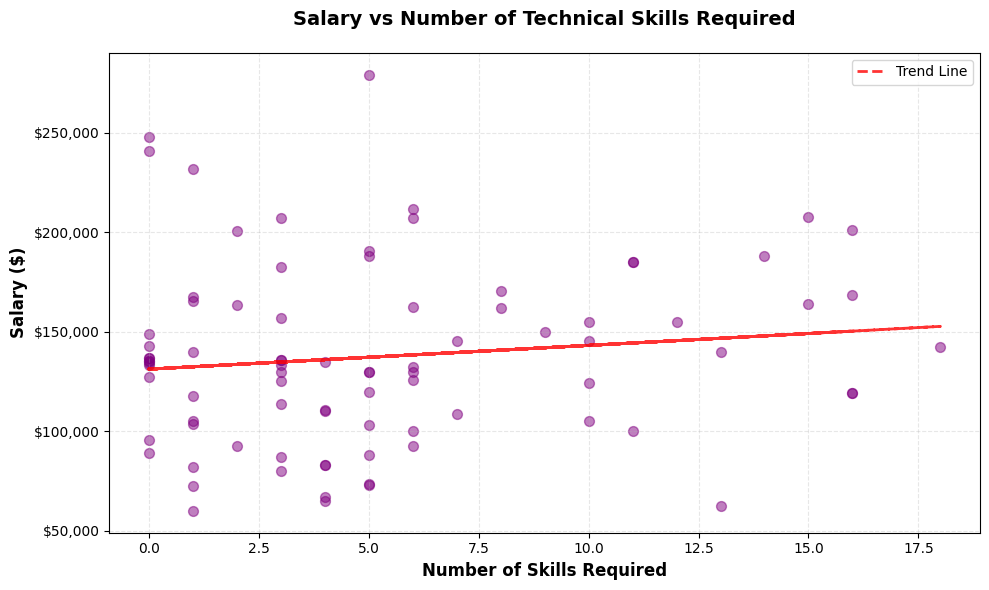


Correlation between number of skills and salary: 0.125
Career Insight: Salary is influenced by factors beyond just the number of skills


In [67]:
# Visualization 4: Salary vs Number of Skills Required
# Analyze relationship between skill requirements and salary
plt.figure(figsize=(10, 6))
plt.scatter(df['skill_count'], df['salary_numeric'], alpha=0.5, s=50, color='purple')
plt.xlabel('Number of Skills Required', fontsize=12, fontweight='bold')
plt.ylabel('Salary ($)', fontsize=12, fontweight='bold')
plt.title('Salary vs Number of Technical Skills Required', fontsize=14, fontweight='bold', pad=20)
plt.grid(alpha=0.3, linestyle='--')

# Format y-axis as currency
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add trend line
z = np.polyfit(df['skill_count'], df['salary_numeric'], 1)
p = np.poly1d(z)
plt.plot(df['skill_count'], p(df['skill_count']), "r--", alpha=0.8, linewidth=2, label='Trend Line')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['skill_count'].corr(df['salary_numeric'])
print(f"\nCorrelation between number of skills and salary: {correlation:.3f}")
if correlation > 0.3:
    print("Career Insight: Jobs requiring more technical skills tend to offer higher salaries")
elif correlation < -0.3:
    print("Career Insight: Specialized roles with fewer skills may command premium salaries")
else:
    print("Career Insight: Salary is influenced by factors beyond just the number of skills")

In [68]:
# Summary Report: Key Career Insights
print("="*70)
print("JOB MARKET ANALYSIS - KEY INSIGHTS")
print("="*70)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total job postings analyzed: {len(df):,}")
print(f"   • Average salary: ${df['salary_numeric'].mean():,.0f}")
print(f"   • Median salary: ${df['salary_numeric'].median():,.0f}")
print(f"   • Salary range: ${df['salary_numeric'].min():,.0f} - ${df['salary_numeric'].max():,.0f}")

print(f"\n💼 TOP IN-DEMAND SKILLS:")
for i, (skill, count) in enumerate(top_skills[:10], 1):
    percentage = (count / len(df)) * 100
    print(f"   {i:2d}. {skill.title():30s} - {count:4d} jobs ({percentage:5.1f}%)")

print(f"\n💰 HIGHEST PAYING SKILL CATEGORIES:")
sorted_categories = sorted(category_salaries.items(), key=lambda x: x[1], reverse=True)
for i, (category, salary) in enumerate(sorted_categories[:5], 1):
    print(f"   {i}. {category:25s} - ${salary:,.0f}")

print(f"\n🎯 CAREER RECOMMENDATIONS:")
print(f"   1. Focus on mastering: {top_skills[0][0].title()}, {top_skills[1][0].title()}, {top_skills[2][0].title()}")
print(f"   2. Develop complementary skill pairs for broader opportunities")
print(f"   3. Consider specializing in {sorted_categories[0][0]} for highest earning potential")
print(f"   4. Average jobs require {df['skill_count'].mean():.1f} technical skills")

print("\n" + "="*70)

JOB MARKET ANALYSIS - KEY INSIGHTS

📊 DATASET OVERVIEW:
   • Total job postings analyzed: 85
   • Average salary: $137,519
   • Median salary: $134,500
   • Salary range: $60,000 - $279,100

💼 TOP IN-DEMAND SKILLS:
    1. Machine Learning               -   39 jobs ( 45.9%)
    2. Python                         -   37 jobs ( 43.5%)
    3. Sql                            -   37 jobs ( 43.5%)
    4. R                              -   26 jobs ( 30.6%)
    5. Spark                          -   18 jobs ( 21.2%)
    6. Aws                            -   18 jobs ( 21.2%)
    7. Azure                          -   18 jobs ( 21.2%)
    8. Tableau                        -   16 jobs ( 18.8%)
    9. Power Bi                       -   10 jobs ( 11.8%)
   10. Data Modeling                  -   10 jobs ( 11.8%)

💰 HIGHEST PAYING SKILL CATEGORIES:
   1. AI/ML                     - $155,072
   2. Cloud & DevOps            - $146,846
   3. Databases                 - $141,660
   4. Data & Analytics        

In [69]:
# Export cleaned data with skills analysis
df_export = df[['positionName', 'company', 'location', 'salary', 'salary_numeric', 
                 'job_title', 'skills', 'skill_count', 'description']].copy()

# Convert skills list to string for Excel export
df_export['skills'] = df_export['skills'].apply(lambda x: ', '.join(x) if x else '')

# Save to Excel
df_export.to_excel("../job_summary/cleaned_jobs.xlsx", index=False)
print(f"✅ Exported {len(df_export)} jobs with skills analysis to cleaned_jobs.xlsx")

✅ Exported 85 jobs with skills analysis to cleaned_jobs.xlsx
